NO 1

=== Jumlah Penumpang per Kelas & Gender ===
Kelas 1 -> Male: 122, Female: 94
Kelas 2 -> Male: 108, Female: 76
Kelas 3 -> Male: 347, Female: 144


C:\Users\LOQ\AppData\Local\Temp\ipykernel_3100\4163671191.py:67: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([umur_tidak, umur_selamat],


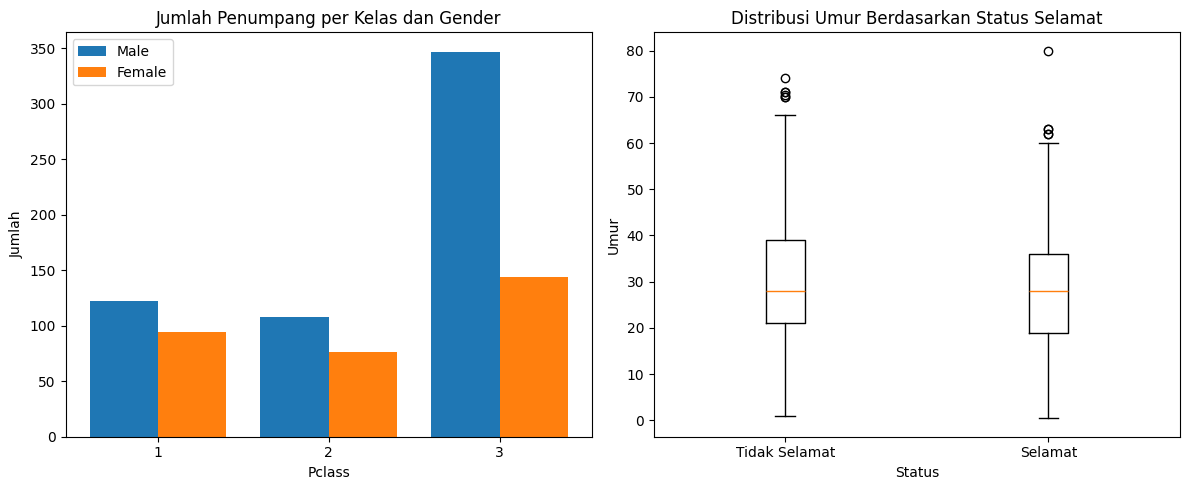

In [1]:
import csv
import matplotlib.pyplot as plt

# BACA DATA CSV
pclass = []
sex = []
survived = []
age = []

with open("soal1.csv", newline='') as file:
    reader = csv.DictReader(file)
    for row in reader:
        pclass.append(int(row['Pclass']))
        sex.append(row['Sex'])
        survived.append(int(row['Survived']))
        
        if row['Age'] != '':
            age.append(float(row['Age']))
        else:
            age.append(None)

# HITUNG JUMLAH KELAS & GENDER
data_count = {}

for i in range(len(pclass)):
    key = (pclass[i], sex[i])
    data_count[key] = data_count.get(key, 0) + 1

# OUTPUT (HANYA INI)
print("=== Jumlah Penumpang per Kelas & Gender ===")
for k in sorted(set(pclass)):
    print(f"Kelas {k} -> Male: {data_count.get((k,'male'),0)}, Female: {data_count.get((k,'female'),0)}")

# SIAPKAN DATA PLOT
kelas = [1,2,3]
male = [data_count.get((k,'male'),0) for k in kelas]
female = [data_count.get((k,'female'),0) for k in kelas]

umur_selamat = []
umur_tidak = []

for i in range(len(survived)):
    if age[i] is not None:
        if survived[i] == 1:
            umur_selamat.append(age[i])
        else:
            umur_tidak.append(age[i])

# VISUALISASI
plt.figure(figsize=(12,5))

# BAR PLOT
plt.subplot(1,2,1)
x = range(len(kelas))

plt.bar([i-0.2 for i in x], male, width=0.4, label='Male')
plt.bar([i+0.2 for i in x], female, width=0.4, label='Female')

plt.xticks(x, kelas)
plt.title("Jumlah Penumpang per Kelas dan Gender")
plt.xlabel("Pclass")
plt.ylabel("Jumlah")
plt.legend()

# BOX PLOT
plt.subplot(1,2,2)
plt.boxplot([umur_tidak, umur_selamat],
            labels=["Tidak Selamat", "Selamat"])

plt.title("Distribusi Umur Berdasarkan Status Selamat")
plt.xlabel("Status")
plt.ylabel("Umur")

plt.tight_layout()
plt.show()

NO 2

=== ANALISIS NILAI SISWA ===

Math Score:
Min   : 0
Max   : 100
Median: 66.0

Reading Score:
Min   : 17
Max   : 100
Median: 70.0


C:\Users\LOQ\AppData\Local\Temp\ipykernel_3100\4143833697.py:60: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([math_score, reading_score],


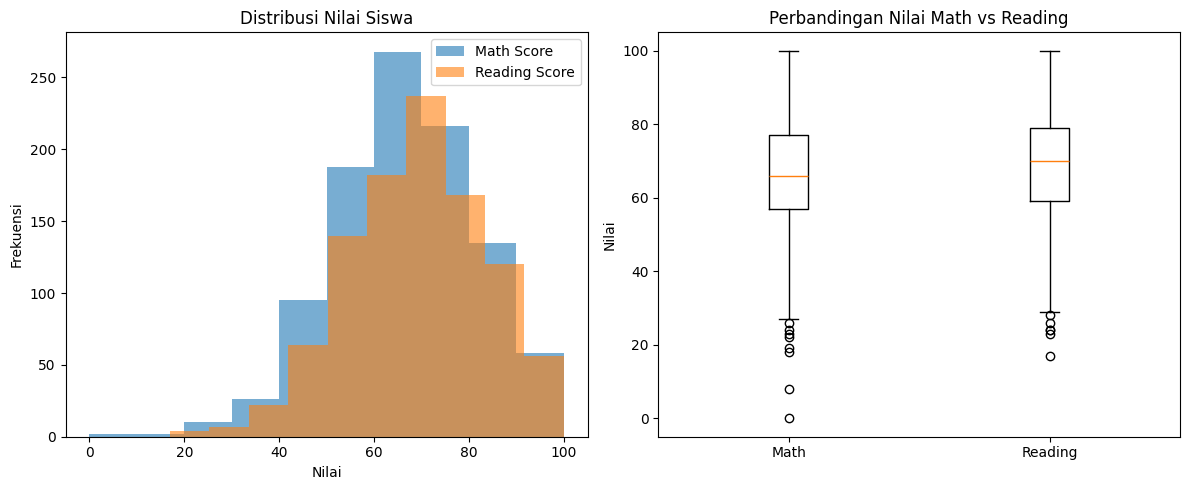

In [2]:
import csv                      # untuk membaca file CSV tanpa pandas
import matplotlib.pyplot as plt  # untuk membuat grafik

# BACA DATA CSV
math_score = []       # list untuk menyimpan nilai matematika
reading_score = []    # list untuk menyimpan nilai membaca

# membuka file CSV
with open("soal2.csv", newline='') as file:
    reader = csv.DictReader(file)   # membaca CSV dalam bentuk dictionary (berdasarkan nama kolom)
    
    for row in reader:              
        math_score.append(int(row['math score']))      # ambil nilai math lalu ubah ke integer
        reading_score.append(int(row['reading score']))# ambil nilai reading lalu ubah ke integer

# FUNGSI HITUNG MEDIAN
def median(data):
    data_sorted = sorted(data)  # mengurutkan data dari kecil ke besar
    n = len(data_sorted)        # menghitung jumlah data
    
    if n % 2 == 0:  # jika jumlah data genap
        # median = rata-rata dua nilai tengah
        return (data_sorted[n//2 - 1] + data_sorted[n//2]) / 2
    else:           
        return data_sorted[n//2]  # ambil nilai tengah langsung

print("=== ANALISIS NILAI SISWA ===\n")  

# analisis math
print("Math Score:")
print("Min   :", min(math_score))       
print("Max   :", max(math_score))       
print("Median:", median(math_score))     

# analisis reading
print("\nReading Score:")
print("Min   :", min(reading_score))     
print("Max   :", max(reading_score))     
print("Median:", median(reading_score))  

# PLOT
plt.figure(figsize=(12,5))  # membuat kanvas gambar ukuran 12x5

# ===== HISTOGRAM =====
plt.subplot(1,2,1)  # membuat subplot ke-1 (1 baris, 2 kolom)

# membuat histogram math & reading
plt.hist(math_score, bins=10, alpha=0.6, label='Math Score')
plt.hist(reading_score, bins=10, alpha=0.6, label='Reading Score')

plt.title("Distribusi Nilai Siswa")  # judul grafik
plt.xlabel("Nilai")                  # label sumbu X
plt.ylabel("Frekuensi")              # label sumbu Y
plt.legend()                         # menampilkan legenda

#BOX PLOT 
plt.subplot(1,2,2)  # subplot ke-2

# membuat box plot untuk membandingkan dua data
plt.boxplot([math_score, reading_score],
            labels=["Math", "Reading"])

plt.title("Perbandingan Nilai Math vs Reading")
plt.ylabel("Nilai")

# TAMPILKAN GRAFIK
plt.tight_layout()  
plt.show()          